# Лабораторная работа №1. Регрессия и метод главных компонент

## 1. Введение

- **Цель работы:** изучение основ линейной регрессии, построение простейших моделей регрессии, проведение обучения модели на реальных данных и оценка её качество.
- **Задачи:**
  1. Загрузить датасет Home Value Insights (`house_price_regression_dataset.csv`).
  2. Подготовить данные: провести первичный анализ, визуализировать распределение признаков и целевой переменной. 
  3. Провести предобработку данных: удалить пропущенные значения, закодировать категориальные переменные (опционально).
  4. Построить матрицу корреляций. Сделать выводы о наличии мультиколлинеарности (расчет VIF-коэффициента).
  5. Построить регрессионные модели (линейная, лассо и гребневая). Если целевая переменная - категориальная, то исследовать логистическую регрессию. Разделить на тренировочную и тестовую выборки (80/20 или 70/30). Использовать кросс-валидацию. Оценить качество построенной модели с помощью метрик: RMSE (Root Mean Square Error), R² (коэффициент детерминации) и MAPE (Mean Absolute Percentage Error).
  6. Устранить мультиколлинеарность и снизить размерность признаков с помощью метода главных компонент (PCA). Перед проведением PCA провести стандартизацию данных.
  7. Повторить шаг 5 (линейная, лассо и гребневая регрессия), но использовать в качестве признаков не исходные данные, а главные компоненты. Сравнить метрики качества (RMSE, R² и MAPE) моделей, обученных на исходных данных и на главных компонентах.
- **Целевая переменная:** `Цена дома` ($) является непрерывной, а значит логистическая регрессия не строится.


## 2. Описание датасета

Датасет [Home Value Insights](https://www.kaggle.com/datasets/prokshitha/home-value-insights): 1000 строк, 8 признаков. Признаки - площадь, спальни, ванные, год постройки, участок, гараж, качество района; цель - цена дома в долларах.

In [2]:
df_raw = pd.read_csv("house_price_regression_dataset.csv")
print(f"Размерность исходного датасета: {df_raw.shape[0]} строк, {df_raw.shape[1]} столбцов\n")

col_map = {
    "Square_Footage": "Площадь",
    "Num_Bedrooms": "Спальни",
    "Num_Bathrooms": "Ванные",
    "Year_Built": "Год постройки",
    "Lot_Size": "Участок",
    "Garage_Size": "Гараж",
    "Neighborhood_Quality": "Качество района",
    "House_Price": "Цена дома",
}
df = df_raw.rename(columns=col_map)

print("Первые 5 строк:")
display(df.head())
print("Типы столбцов:")
display(df.dtypes.to_frame("Тип"))
print("Пропуски:")
display(df.isnull().sum().to_frame("Пропуски"))

duplicates_count = int(df.duplicated().sum())
if duplicates_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Удалено дубликатов: {duplicates_count}. Новый размер: {df.shape}")
else:
    print("Дубликаты не обнаружены.")
    print(f"Рабочий размер таблицы: {df.shape}")

Размерность исходного датасета: 1000 строк, 8 столбцов

Первые 5 строк:


,Площадь,Спальни,Ванные,Год постройки,Участок,Гараж,Качество района,Цена дома
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


Типы столбцов:


,Тип
Площадь,int64
Спальни,int64
Ванные,int64
Год постройки,int64
Участок,float64
Гараж,int64
Качество района,int64
Цена дома,float64


Пропуски:


,Пропуски
Площадь,0
Спальни,0
Ванные,0
Год постройки,0
Участок,0
Гараж,0
Качество района,0
Цена дома,0


Дубликаты не обнаружены.
Рабочий размер таблицы: (1000, 8)


### Пояснение к первичному анализу данных

- **Объём:** 1000 объектов × 8 столбцов. Пропусков (`NaN`) нет.
- **Дубликаты:** полностью совпадающих строк нет, выборка остаётся 1000 объектов.
- **Структура:** все признаки числовые. Непрерывные - `Площадь`, `Участок`, `Цена дома`; дискретные - `Спальни`, `Ванные`, `Гараж`, `Качество района`, `Год постройки`. Категориальных текстовых полей нет.


In [3]:
numeric_cols = list(df.columns)
stats_df = df[numeric_cols].describe().T
stats_df["Медиана"] = df[numeric_cols].median()
stats_df["Мода"] = [df[c].mode().iloc[0] for c in numeric_cols]
stats_df["IQR"] = stats_df["75%"] - stats_df["25%"]
stats_df["Асимметрия"] = df[numeric_cols].skew()
stats_df = stats_df.rename(columns={
    "count": "Количество", "mean": "Среднее", "std": "Станд. откл.",
    "min": "Мин.", "25%": "25%", "50%": "50%", "75%": "75%", "max": "Макс.",
})
print("Описательная статистика:")
display(stats_df[[
    "Количество", "Среднее", "Станд. откл.", "Медиана", "Мода",
    "IQR", "Мин.", "Макс.", "Асимметрия"
]].round(2))

Описательная статистика:


,Количество,Среднее,Станд. откл.,Медиана,Мода,IQR,Мин.,Макс.,Асимметрия
Площадь,1000.0,2815.42,1255.51,2862.50,1743.00,2100.00,503.00,4999.00,-0.07
Спальни,1000.0,2.99,1.43,3.00,2.00,2.00,1.00,5.00,0.03
Ванные,1000.0,1.97,0.82,2.00,1.00,2.00,1.00,3.00,0.05
Год постройки,1000.0,1986.55,20.63,1986.00,1996.00,35.25,1950.00,2022.00,-0.02
Участок,1000.0,2.78,1.30,2.81,0.51,2.26,0.51,4.99,-0.04
Гараж,1000.0,1.02,0.81,1.00,2.00,2.00,0.00,2.00,-0.04
Качество района,1000.0,5.62,2.89,6.00,10.00,5.00,1.00,10.00,-0.02
Цена дома,1000.0,618861.02,253568.06,628267.29,111626.85,425493.05,111626.85,1108236.84,-0.06


### Пояснение к описательной статистике

- **Цена дома:** среднее ~ $618 861, медиана ~ $628 267, асимметрия близка к нулю. Диапазон широкий (~ $112 тыс. – $1.11 млн).
- **Площадь:** среднее ~ 2815 кв. футов (503–4999).
- **Остальные признаки:** участок ~ 2.78 акра; год постройки ~ 1986 (1950–2022); спальни 1–5, ванные 1–3, гараж 0–2, качество района 1–10.
- **Масштабы разные** значит, перед Ridge/Lasso/PCA нужна стандартизация.

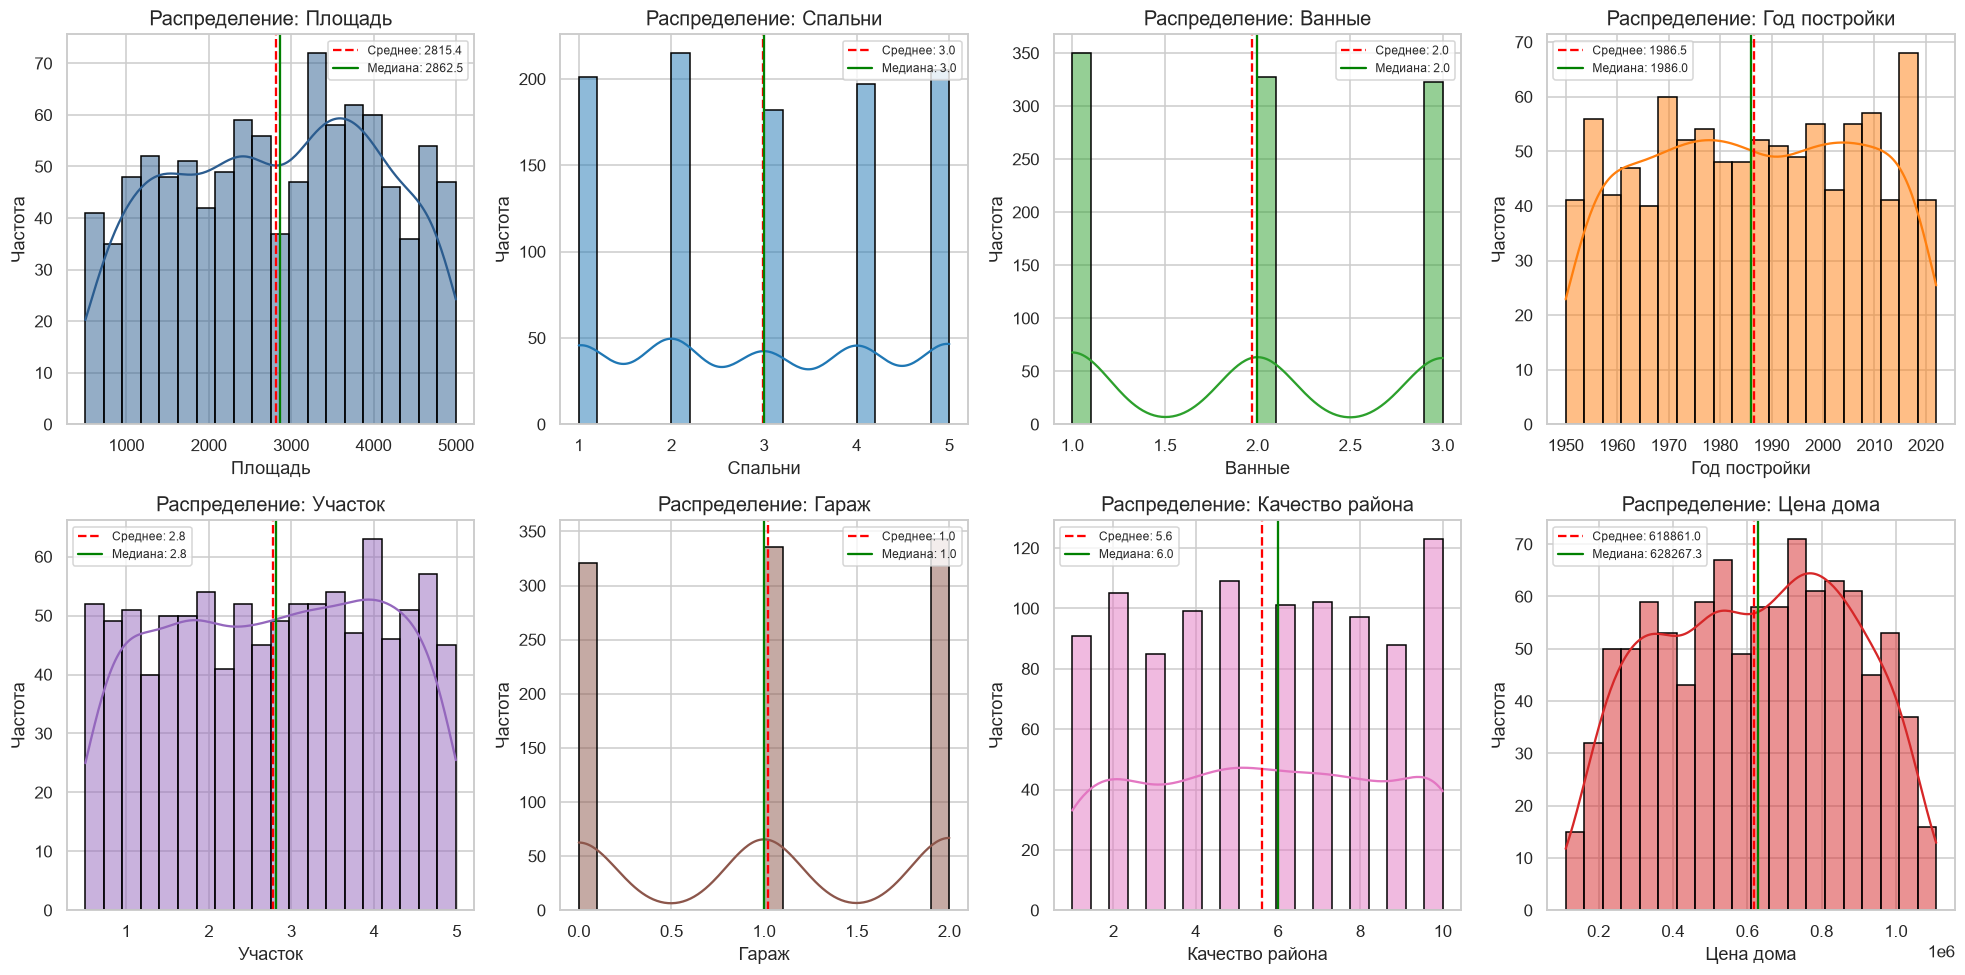

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
colors = ["#2b5c8f", "#1f77b4", "#2ca02c", "#ff7f0e", "#9467bd", "#8c564b", "#e377c2", "#d62728"]
for ax, col, color in zip(axes.ravel(), numeric_cols, colors):
    sns.histplot(df[col], kde=True, ax=ax, color=color, bins=20, edgecolor="black")
    ax.axvline(df[col].mean(), color="red", linestyle="--", label=f"Среднее: {df[col].mean():.1f}")
    ax.axvline(df[col].median(), color="green", linestyle="-", label=f"Медиана: {df[col].median():.1f}")
    ax.set_title(f"Распределение: {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Частота")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Пояснение к графикам распределения признаков

Гистограммы показывают разброс признаков и цены. Цена занимает широкий интервал без резкого правого хвоста — логарифмировать цель необязательно. `Площадь`, `Участок` и `Год постройки` заполняют диапазоны относительно равномерно. Дискретные признаки дают отдельные столбцы на целых значениях. Явных сбоев записи нет.

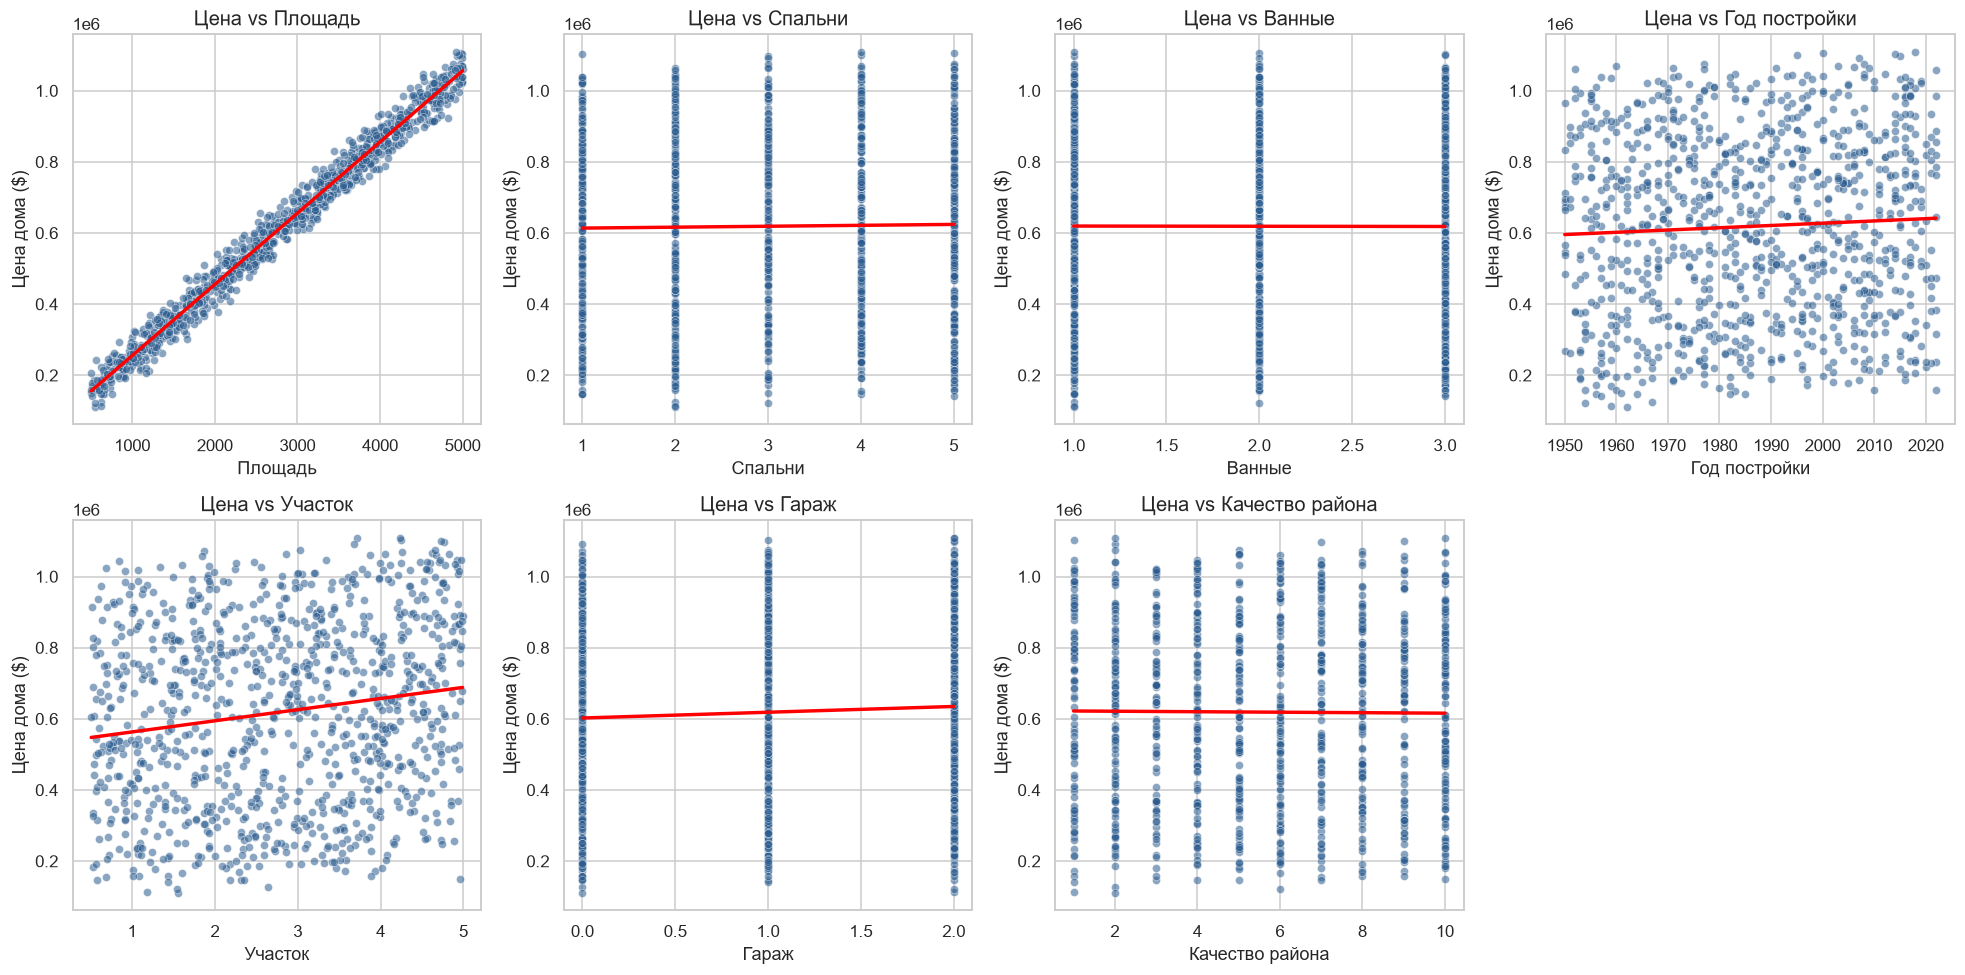

In [ ]:
features = [c for c in df.columns if c != "Цена дома"]
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, col in zip(axes.ravel(), features):
    sns.scatterplot(data=df, x=col, y="Цена дома", ax=ax, alpha=0.55, s=28, color="#2b5c8f")
    sns.regplot(data=df, x=col, y="Цена дома", scatter=False, ax=ax, color="red", ci=None)
    ax.set_title(f"Цена vs {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Цена дома ($)")
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()

### Пояснение к зависимости цены от признаков

Самая ясная связь - `Площадь х Цена`: точки почти на прямой. У участка слабый положительный наклон. Год постройки, гараж, спальни, ванные и качество района выглядят как вертикальные полосы. Практически: основной предиктор - площадь; остальные признаки слабые.

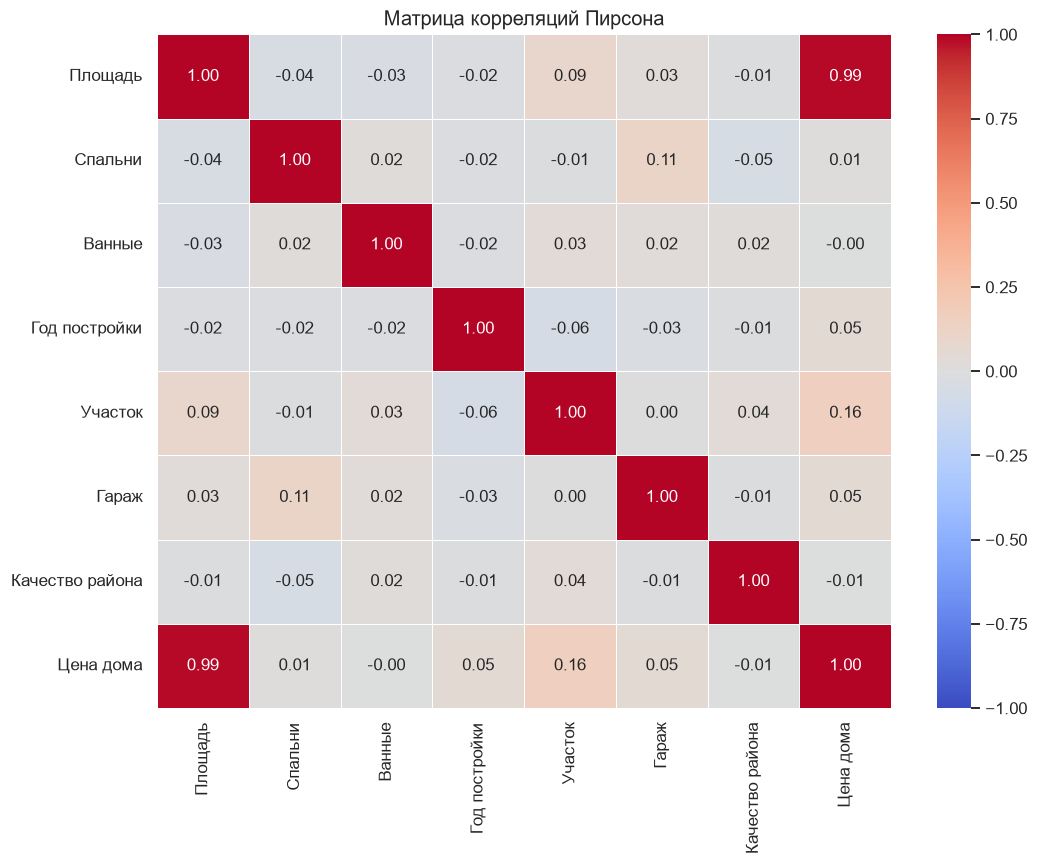

Корреляция признаков с ценой:


,Корреляция с ценой
Площадь,0.991
Участок,0.160
Гараж,0.052
Год постройки,0.052
Спальни,0.015
Ванные,-0.002
Качество района,-0.008


Корреляция Площадь–Цена: r = 0.991


In [6]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Матрица корреляций Пирсона")
plt.tight_layout()
plt.show()

print("Корреляция признаков с ценой:")
display(
    corr_matrix["Цена дома"].drop("Цена дома").sort_values(ascending=False)
    .round(3).to_frame("Корреляция с ценой")
)

r_sqft = float(corr_matrix.loc["Площадь", "Цена дома"])
print(f"Корреляция Площадь–Цена: r = {r_sqft:.3f}")

### Пояснение к матрице корреляций

- **С ценой:** `Площадь` даёт $r \approx 0.991$. `Участок` ≈ 0.16; год постройки и гараж ≈ 0.05; спальни, ванные, качество района ≈ 0.
- **Между предикторами:** взаимные корреляции малы ($|r|$ в основном $< 0.12$). Парной мультиколлинеарности не видно.

,Признак,VIF
0,Спальни,1.018
1,Гараж,1.016
2,Участок,1.014
3,Площадь,1.013
4,Год постройки,1.005
5,Качество района,1.004
6,Ванные,1.004


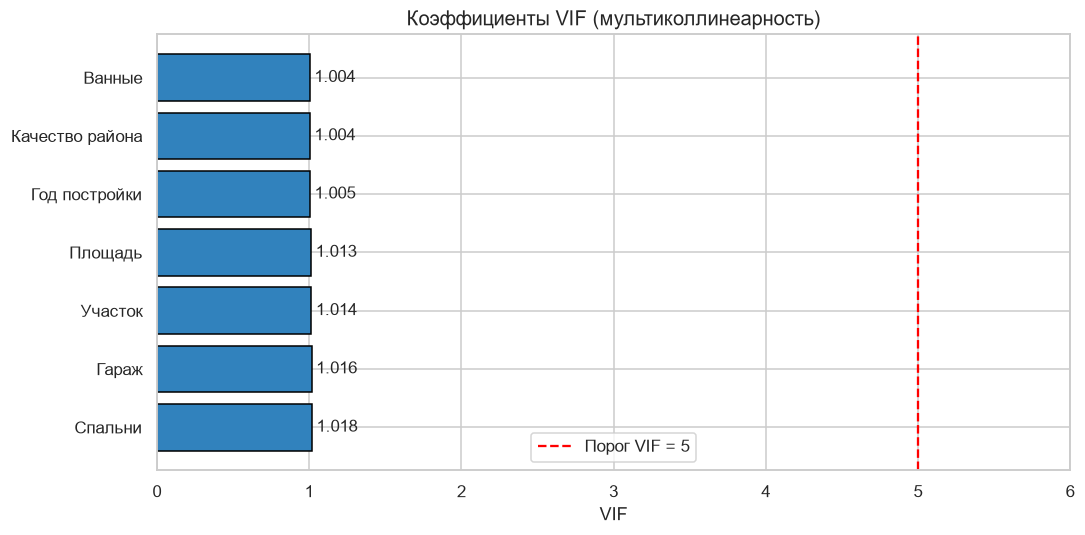

In [7]:
X_all = df.drop(columns=["Цена дома"])
scaler_vif = StandardScaler()
X_vif = pd.DataFrame(scaler_vif.fit_transform(X_all), columns=X_all.columns)

vif_df = pd.DataFrame({
    "Признак": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
})
vif_df = vif_df.sort_values("VIF", ascending=False).reset_index(drop=True)
display(vif_df.round(3))

plt.figure(figsize=(10, 5))
bars = plt.barh(vif_df["Признак"], vif_df["VIF"], color="#3182bd", edgecolor="black")
plt.axvline(5.0, color="red", linestyle="--", linewidth=1.5, label="Порог VIF = 5")
plt.title("Коэффициенты VIF (мультиколлинеарность)")
plt.xlabel("VIF")
for bar in bars:
    val = bar.get_width()
    plt.text(val + 0.03, bar.get_y() + bar.get_height() / 2, f"{val:.3f}", va="center")
plt.xlim(0, 6)
plt.legend()
plt.tight_layout()
plt.show()

### Пояснение к VIF

$$
VIF_i = \frac{1}{1 - R_i^2}
$$

Ориентиры: $VIF < 5$ — мультиколлинеарности нет; $5$–$10$ — умеренная; $> 10$ — критическая. Здесь все VIF ≈ **1.004–1.018**. Предикторы почти ортогональны, а это обеспечивает высокую устойчивость оценок линейной регрессии.

## 3. Подготовка данных

Пропуски, дубликаты, корреляции и VIF были разобраны раннее, категорий для кодирования нет. Разбиваем на тренировочную и тестовую выборки (80/20) и стандартизируем.

In [8]:
X = df.drop(columns=["Цена дома"])
y = df["Цена дома"]
feature_names = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_names)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_names)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"Обучающая выборка: {X_train.shape[0]} объектов")
print(f"Тестовая выборка: {X_test.shape[0]} объектов")
print(f"Число признаков: {X_train.shape[1]}")
print(f"Средняя цена на обучении, $: {y_train.mean():.2f}")
print("\nСредние стандартизованных признаков на обучении (ожидаются ≈ 0):")
display(X_train_scaled.mean().round(8).to_frame("Среднее"))

Обучающая выборка: 800 объектов
Тестовая выборка: 200 объектов
Число признаков: 7
Средняя цена на обучении, $: 618576.05

Средние стандартизованных признаков на обучении (ожидаются ≈ 0):


,Среднее
Площадь,-0.0
Спальни,0.0
Ванные,0.0
Год постройки,0.0
Участок,-0.0
Гараж,0.0
Качество района,-0.0


### Пояснение к предобработке и разбиению

- **Train/test:** 800 / 200 объектов (`test_size=0.2`, `random_state=42`).
- **Стандартизация:** $z=(x-\mu)/\sigma$. Параметры считаются **только на train** (`fit`), к тесту применяется `transform`. Цена не стандартизируется.
- **Кросс-валидация:** 5 блоков с перемешиванием на обучающей выборке. Тест в подборе не участвует.

## 4. Ход работы. Регрессия на исходных признаках

Строим OLS, Ridge и Lasso. Параметр `alpha` для Ridge/Lasso **подбираем** через `GridSearchCV` по сетке значений. Линейная модель обучается вызовом `model_lin.fit`.

Подбор гиперпараметров (GridSearchCV, 5-fold, метрика R²)
Сетка alpha: [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 500.0, 1000.0]
Лучший alpha Ridge: 0.01 (CV R² = 0.998478)
Лучший alpha Lasso: 100.0 (CV R² = 0.998480)


,alpha,Ridge CV R²,Lasso CV R²
0,0.01,0.998478,0.998478
1,0.10,0.998478,0.998478
2,1.00,0.998475,0.998478
3,10.00,0.998232,0.998478
4,50.00,0.993081,0.998479
5,100.00,0.979803,0.998480
6,500.00,0.804634,0.998461
7,1000.00,0.624808,0.998395


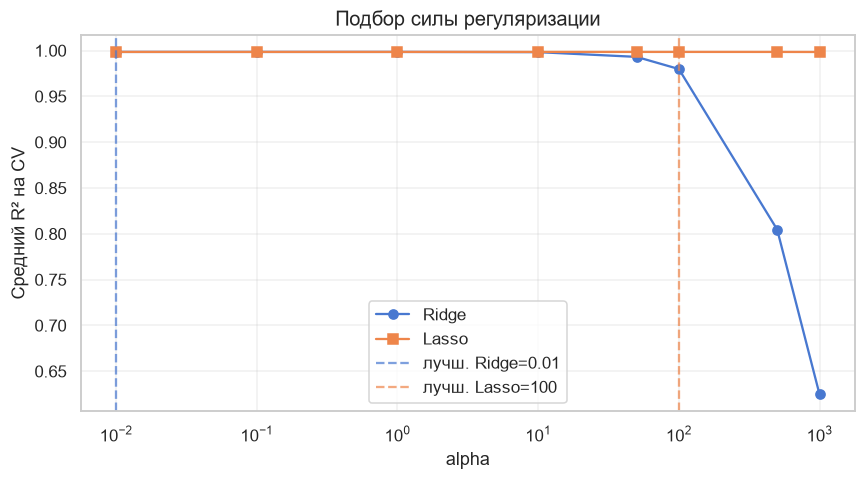

In [9]:
alpha_grid = {"alpha": [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 500.0, 1000.0]}

ridge_search = GridSearchCV(
    Ridge(random_state=42), alpha_grid, cv=kf, scoring="r2", n_jobs=-1
)
ridge_search.fit(X_train_scaled, y_train)
best_ridge_alpha = float(ridge_search.best_params_["alpha"])

lasso_search = GridSearchCV(
    Lasso(max_iter=20000, random_state=42), alpha_grid, cv=kf, scoring="r2", n_jobs=-1
)
lasso_search.fit(X_train_scaled, y_train)
best_lasso_alpha = float(lasso_search.best_params_["alpha"])

print("Подбор гиперпараметров (GridSearchCV, 5-fold, метрика R²)")
print(f"Сетка alpha: {alpha_grid['alpha']}")
print(f"Лучший alpha Ridge: {best_ridge_alpha} (CV R² = {ridge_search.best_score_:.6f})")
print(f"Лучший alpha Lasso: {best_lasso_alpha} (CV R² = {lasso_search.best_score_:.6f})")

ridge_cv = pd.DataFrame({
    "alpha": alpha_grid["alpha"],
    "Ridge CV R²": ridge_search.cv_results_["mean_test_score"],
})
lasso_cv = pd.DataFrame({
    "alpha": alpha_grid["alpha"],
    "Lasso CV R²": lasso_search.cv_results_["mean_test_score"],
})
display(ridge_cv.merge(lasso_cv, on="alpha").round(6))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogx(ridge_cv["alpha"], ridge_cv["Ridge CV R²"], "o-", label="Ridge")
ax.semilogx(lasso_cv["alpha"], lasso_cv["Lasso CV R²"], "s-", label="Lasso")
ax.axvline(best_ridge_alpha, color="C0", linestyle="--", alpha=0.7, label=f"лучш. Ridge={best_ridge_alpha:g}")
ax.axvline(best_lasso_alpha, color="C1", linestyle="--", alpha=0.7, label=f"лучш. Lasso={best_lasso_alpha:g}")
ax.set_xlabel("alpha")
ax.set_ylabel("Средний R² на CV")
ax.set_title("Подбор силы регуляризации")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Пояснение к подбору `alpha`

Для Ridge и Lasso выполнен перебор `alpha` на сетке $\{0.01, 0.1, 1, 10, 50, 100, 500, 1000\}$ с 5-фолдовой CV по $R^2$. Лучшие значения оказываются на стороне **слабого штрафа**; при больших `alpha` CV-$R^2$ падает. Это **эмпирически подтверждает** вывод из VIF: сильная регуляризация качество не повышает. Дальше модели обучаем с найденными лучшими `alpha`.

In [10]:
model_lin = LinearRegression()
model_ridge = Ridge(alpha=best_ridge_alpha, random_state=42)
model_lasso = Lasso(alpha=best_lasso_alpha, max_iter=20000, random_state=42)

models_orig = {
    "Линейная (OLS)": model_lin,
    f"Ridge (alpha={best_ridge_alpha:g})": model_ridge,
    f"Lasso (alpha={best_lasso_alpha:g})": model_lasso,
}

results_orig = {}
preds_orig = {}

print("=== Модели на исходных стандартизованных признаках ===")
for name, model in models_orig.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring="r2")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    preds_orig[name] = y_pred
    rmse, r2, mape = regression_metrics(y_test, y_pred)
    results_orig[name] = {
        "R2_CV_mean": float(cv_scores.mean()),
        "R2_CV_std": float(cv_scores.std()),
        "R2_Test": r2,
        "RMSE_Test": rmse,
        "MAPE_Test": mape / 100.0,
    }
    print(
        f"{name:<28} | R²(CV): {cv_scores.mean():.4f} | "
        f"R²(тест): {r2:.4f} | RMSE: {rmse:.2f} $ | MAPE: {mape:.2f}%"
    )

df_results_orig = pd.DataFrame([
    {
        "Модель": name,
        "R2 (CV)": res["R2_CV_mean"],
        "R2 (тест)": res["R2_Test"],
        "RMSE": res["RMSE_Test"],
        "MAPE, %": res["MAPE_Test"] * 100,
    }
    for name, res in results_orig.items()
])
display(df_results_orig.round(4))

coef_df = pd.DataFrame({
    "Признак": feature_names,
    "Линейная": model_lin.coef_,
    "Ridge": model_ridge.coef_,
    "Lasso": model_lasso.coef_,
})
print("Коэффициенты при стандартизованных признаках:")
display(coef_df.round(2))
print(f"Свободный член model_lin, $: {model_lin.intercept_:.2f}")
sqft_idx = feature_names.index("Площадь")
print(f"Вклад 1 кв. фута площади, $: {model_lin.coef_[sqft_idx] / scaler.scale_[sqft_idx]:.2f}")

=== Модели на исходных стандартизованных признаках ===
Линейная (OLS)               | R²(CV): 0.9985 | R²(тест): 0.9984 | RMSE: 10071.48 $ | MAPE: 1.66%
Ridge (alpha=0.01)           | R²(CV): 0.9985 | R²(тест): 0.9984 | RMSE: 10071.95 $ | MAPE: 1.66%
Lasso (alpha=100)            | R²(CV): 0.9985 | R²(тест): 0.9984 | RMSE: 10082.26 $ | MAPE: 1.67%


,Модель,R2 (CV),R2 (тест),RMSE,"MAPE, %"
0,Линейная (OLS),0.9985,0.9984,10071.4844,1.6639
1,Ridge (alpha=0.01),0.9985,0.9984,10071.9532,1.6641
2,Lasso (alpha=100),0.9985,0.9984,10082.2622,1.6673


Коэффициенты при стандартизованных признаках:


,Признак,Линейная,Ridge,Lasso
0,Площадь,249787.91,249784.74,249692.53
1,Спальни,14524.73,14524.44,14430.13
2,Ванные,6695.91,6695.70,6606.06
3,Год постройки,20662.12,20661.79,20548.69
4,Участок,19088.11,19088.26,18999.97
5,Гараж,4219.45,4219.58,4132.74
6,Качество района,335.25,335.20,238.81


Свободный член model_lin, $: 618576.05
Вклад 1 кв. фута площади, $: 199.51


### Пояснение к моделям на исходных признаках

- **Метрики:** $R^2 \approx 0.9984$, $RMSE \approx 10$ тыс. $, $MAPE \approx 1.7\%$. CV совпадает с тестом.
- **Ridge/Lasso после GridSearch:** практически не отличаются от OLS.
- **Коэффициенты:** доминирует `Площадь` (≈ $200$ за 1 кв. фут).

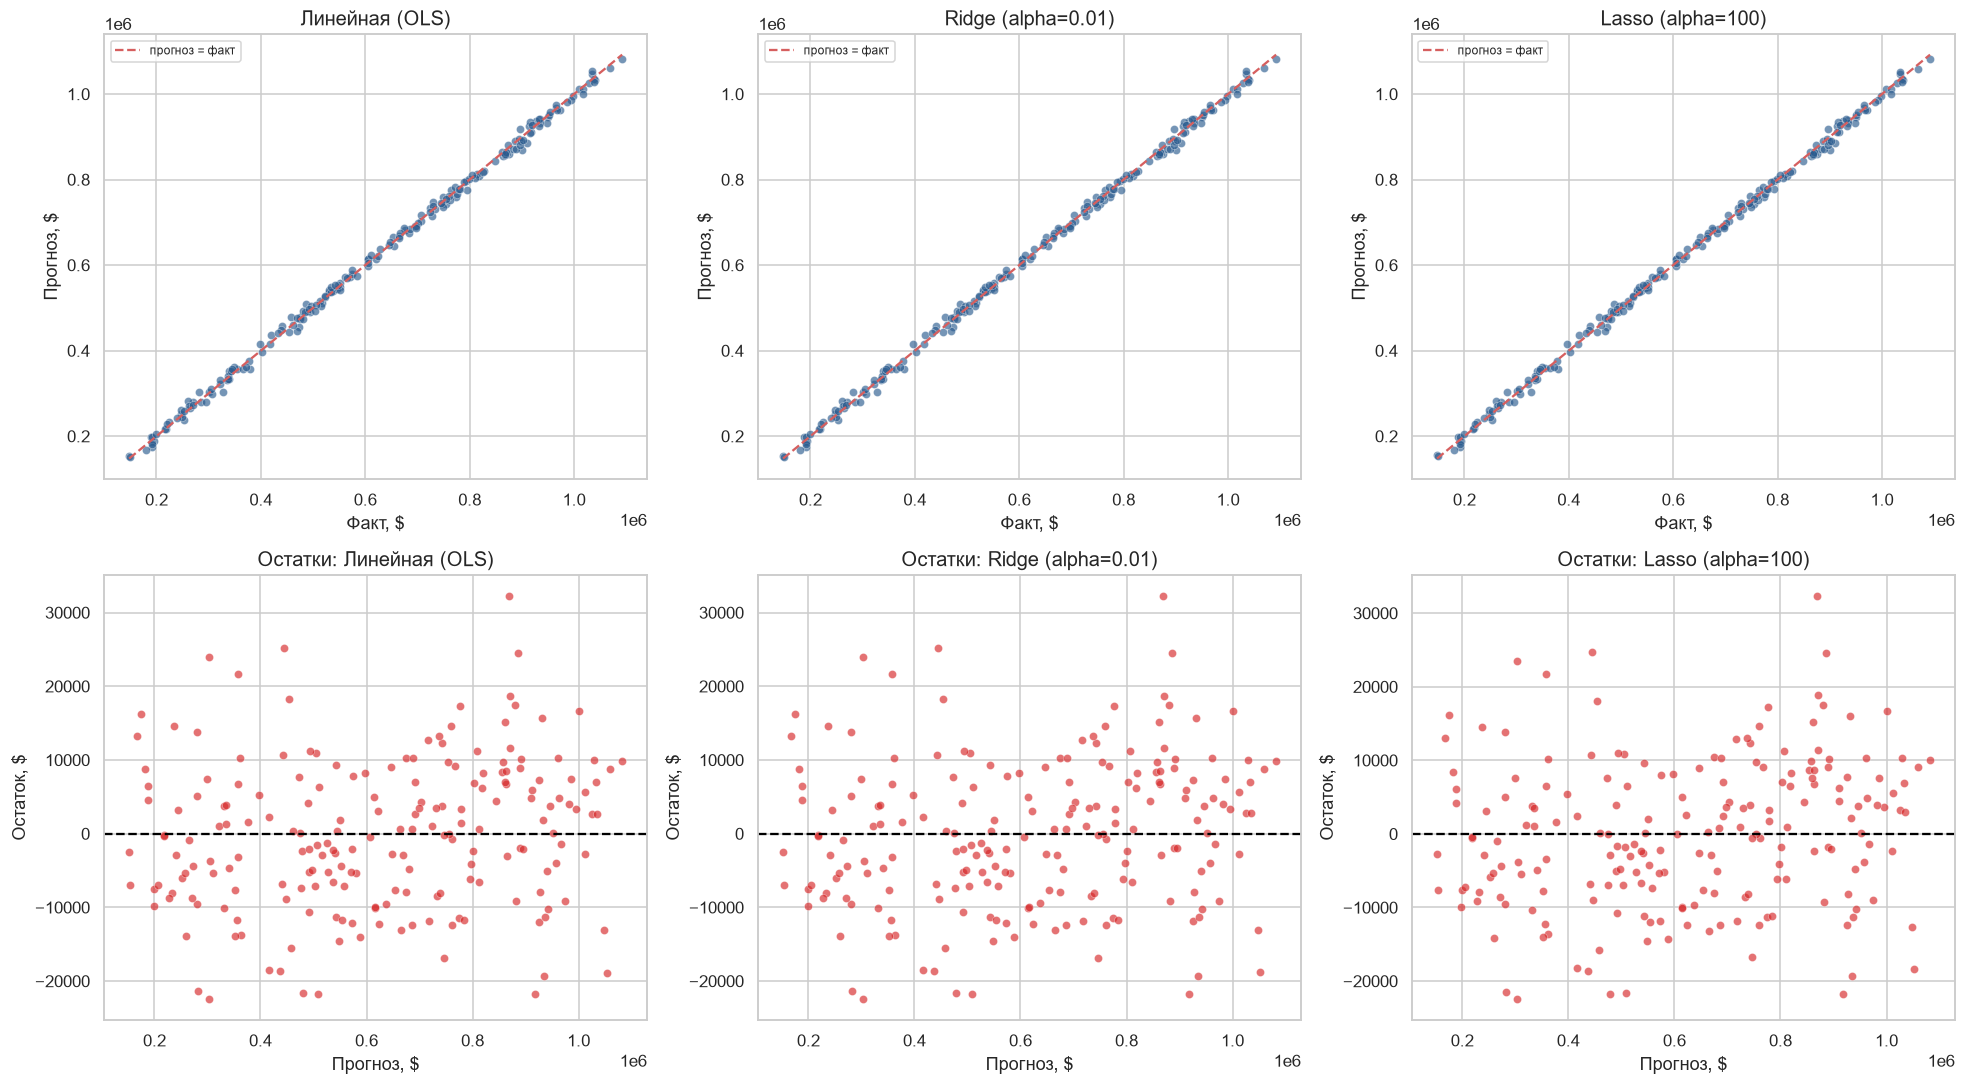

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, (name, model) in enumerate(models_orig.items()):
    y_pred = preds_orig[name]
    ax = axes[0, i]
    ax.scatter(y_test, y_pred, alpha=0.65, s=28, color="#2b5c8f", edgecolor="white", linewidth=0.3)
    low = min(float(y_test.min()), float(y_pred.min()))
    high = max(float(y_test.max()), float(y_pred.max()))
    ax.plot([low, high], [low, high], "r--", label="прогноз = факт")
    ax.set_title(name)
    ax.set_xlabel("Факт, $")
    ax.set_ylabel("Прогноз, $")
    ax.legend(fontsize=8)

    ax_r = axes[1, i]
    residuals = y_test.values - y_pred
    ax_r.scatter(y_pred, residuals, alpha=0.65, s=28, color="#d62728", edgecolor="white", linewidth=0.3)
    ax_r.axhline(0.0, color="black", linestyle="--")
    ax_r.set_title(f"Остатки: {name}")
    ax_r.set_xlabel("Прогноз, $")
    ax_r.set_ylabel("Остаток, $")
plt.tight_layout()
plt.show()

### Пояснение к графикам прогнозов и остатков

Точки плотно лежат на диагонали, факт соответствует прогнозу». Остатки около нуля без сильного веера. OLS, Ridge и Lasso визуально неотличимы. Рабочая модель — **линейная регрессия**.

### Каменистая осыпь, ГК

Перед PCA признаки уже стандартизованы. Сравниваем два правила:
- **Правило Кайзера:** $\lambda > 1$ = 3 ГК;
- **Порог 85% дисперсии** = 6 ГК.


,Главная компонента,Собственное значение,Доля дисперсии,Накопленная доля
0,ГК 1,1.1693,0.1668,0.1668
1,ГК 2,1.1437,0.1632,0.3300
2,ГК 3,1.0607,0.1513,0.4814
3,ГК 4,0.9753,0.1392,0.6205
4,ГК 5,0.9582,0.1367,0.7572
5,ГК 6,0.8814,0.1258,0.8830
6,ГК 7,0.8201,0.1170,1.0000


По Кайзеру (λ > 1): 3 компонент, накопленная дисперсия = 0.4814
По порогу 85%: 6 компонент, накопленная дисперсия = 0.8830


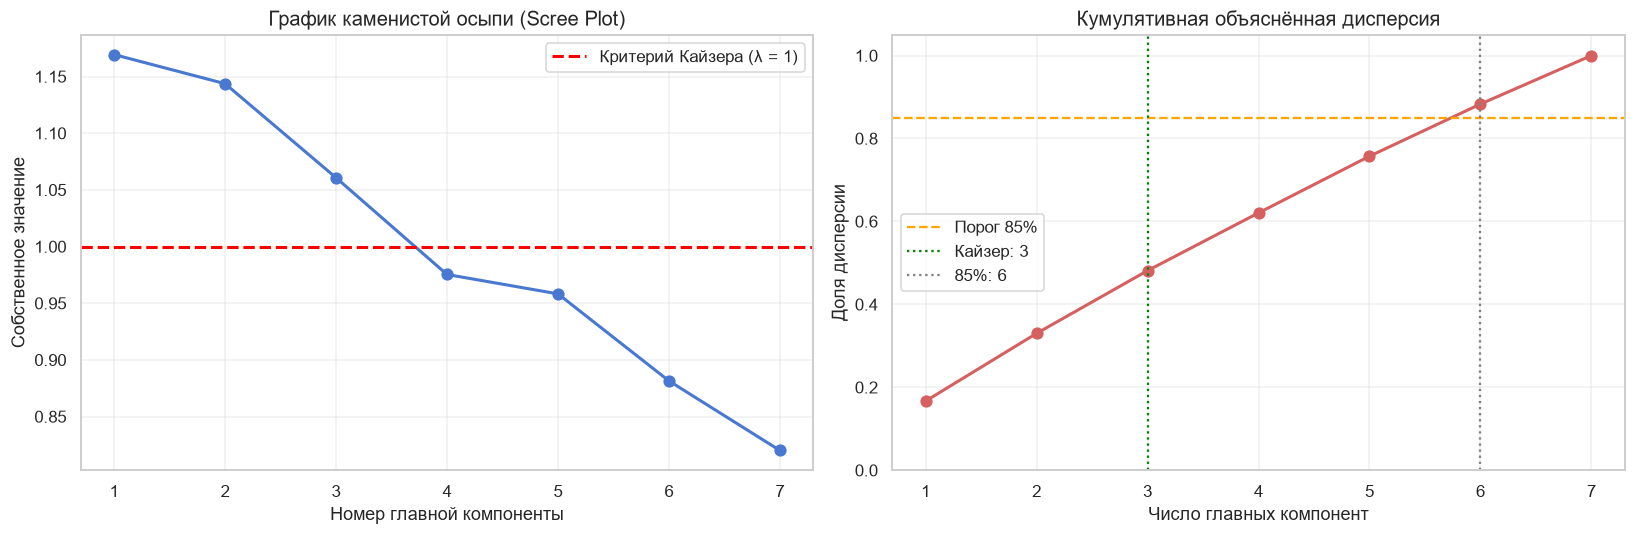

In [12]:
pca_full = PCA().fit(X_train_scaled)
eigenvalues = pca_full.explained_variance_
exp_var_ratio = pca_full.explained_variance_ratio_
cum_var = np.cumsum(exp_var_ratio)

k_kaiser = int(np.sum(eigenvalues > 1))
k_var85 = int(np.argmax(cum_var >= 0.85) + 1)

pca_table = pd.DataFrame({
    "Главная компонента": [f"ГК {i}" for i in range(1, len(eigenvalues) + 1)],
    "Собственное значение": eigenvalues,
    "Доля дисперсии": exp_var_ratio,
    "Накопленная доля": cum_var,
})
display(pca_table.round(4))
print(f"По Кайзеру (λ > 1): {k_kaiser} компонент, накопленная дисперсия = {cum_var[k_kaiser-1]:.4f}")
print(f"По порогу 85%: {k_var85} компонент, накопленная дисперсия = {cum_var[k_var85-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(range(1, len(eigenvalues) + 1), eigenvalues, "bo-", linewidth=2, markersize=7)
axes[0].axhline(1.0, color="red", linestyle="--", linewidth=2, label="Критерий Кайзера (λ = 1)")
axes[0].set_title("График каменистой осыпи (Scree Plot)")
axes[0].set_xlabel("Номер главной компоненты")
axes[0].set_ylabel("Собственное значение")
axes[0].set_xticks(range(1, len(eigenvalues) + 1))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(cum_var) + 1), cum_var, "ro-", linewidth=2, markersize=7)
axes[1].axhline(0.85, color="orange", linestyle="--", label="Порог 85%")
axes[1].axvline(k_kaiser, color="green", linestyle=":", label=f"Кайзер: {k_kaiser}")
axes[1].axvline(k_var85, color="gray", linestyle=":", label=f"85%: {k_var85}")
axes[1].set_title("Кумулятивная объяснённая дисперсия")
axes[1].set_xlabel("Число главных компонент")
axes[1].set_ylabel("Доля дисперсии")
axes[1].set_xticks(range(1, len(cum_var) + 1))
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Пояснение к графику каменистой осыпи

Собственные значения снижаются плавно (≈ 1.17 → 0.82), резкого излома нет. По Кайзеру значимы **3** компоненты (≈ 48% дисперсии). По порогу 85% нужны **6** из 7 (≈ 88%). Оба варианта прогоняем через регрессию.

Факторные нагрузки:


,ГК 1,ГК 2,ГК 3,ГК 4,ГК 5,ГК 6
Площадь,0.365,0.530,-0.303,0.274,0.191,-0.283
Спальни,0.424,-0.523,-0.091,0.202,-0.025,0.590
Ванные,0.236,-0.184,0.646,0.276,-0.437,-0.449
Год постройки,-0.391,-0.073,0.095,0.820,0.376,0.051
Участок,0.385,0.538,0.178,0.221,-0.248,0.448
Гараж,0.569,-0.310,-0.160,0.018,0.404,-0.367
Качество района,0.088,0.144,0.646,-0.295,0.636,0.177



Содержательные подписи, полученные из нагрузок:
ГК 1 — «Гаражно-планировочный профиль»: Гараж (+0.57), Спальни (+0.42), Год постройки (-0.39)
ГК 2 — «Фактор площади дома и участка»: Участок (+0.54), Площадь (+0.53), Спальни (-0.52)
ГК 3 — «Качество района и комфорт санузлов»: Качество района (+0.65), Ванные (+0.65), Площадь (-0.30)
ГК 4 — «Фактор новизны дома»: Год постройки (+0.82), Качество района (-0.29), Ванные (+0.28)
ГК 5 — «Район и гараж vs число ванных»: Качество района (+0.64), Ванные (-0.44), Гараж (+0.40)
ГК 6 — «Спальный профиль планировки»: Спальни (+0.59), Ванные (-0.45), Участок (+0.45)


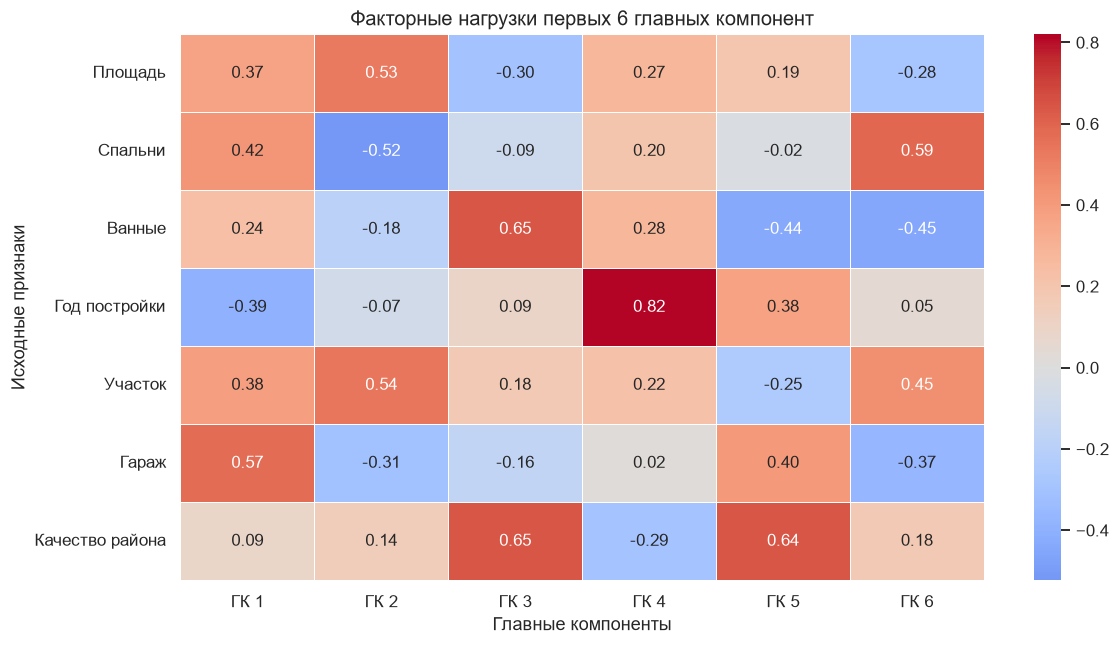

In [ ]:
pca_for_labels = PCA(n_components=k_var85).fit(X_train_scaled)
loadings = pd.DataFrame(
    pca_for_labels.components_.T,
    index=feature_names,
    columns=[f"ГК {i}" for i in range(1, k_var85 + 1)],
)

pc_labels = {}
print("Факторные нагрузки:")
display(loadings.round(3))

print("\nСодержательные подписи, полученные из нагрузок:")
for i in range(1, k_var85 + 1):
    title, detail = label_component(loadings[f"ГК {i}"])
    pc_labels[i] = title
    print(f"ГК {i} — «{title}»: {detail}")

plt.figure(figsize=(11, 6))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title(f"Факторные нагрузки первых {k_var85} главных компонент")
plt.ylabel("Исходные признаки")
plt.xlabel("Главные компоненты")
plt.tight_layout()
plt.show()

### Пояснение к интерпретации главных компонент

Содержательная интерпретация факторных нагрузок:

- **ГК 1** (16.7% дисперсии) — «Гаражно-планировочный профиль»: доминируют положительные нагрузки Гараж (+0.57) и Спальни (+0.42) при отрицательной нагрузке Год постройки (−0.39). Компонента растёт у домов с большим гаражом и числом спален, чаще более старых.

- **ГК 2** (16.3% дисперсии) — «Фактор площади дома и участка»: высокие положительные нагрузки Участок (+0.54) и Площадь (+0.53) при отрицательной нагрузке Спальни (−0.52). Отражает крупные дома/участки, не обязательно с большим числом спален.

- **ГК 3** (15.1% дисперсии) — «Качество района и комфорт санузлов»: почти равные положительные нагрузки Качество района (+0.65) и Ванные (+0.65). Характеризует локацию и санитарный комфорт.

- **ГК 4** (13.9% дисперсии) — «Фактор новизны дома»: почти целиком определяется Год постройки (+0.82). Чем новее дом, тем выше значение компоненты.

- **ГК 5** (13.7% дисперсии) — «Район и гараж vs число ванных»: положительные Качество района (+0.64) и Гараж (+0.40) при отрицательных Ванные (−0.44). Контраст между районом/гаражом и числом санузлов.

- **ГК 6** (12.6% дисперсии) — «Спальный профиль планировки»: сильная нагрузка Спальни (+0.59) при обратной связи с Ванные (−0.45) и положительной с Участок (+0.45). Ось планировки комнат.

Все полученные главные компоненты строго ортогональны, поэтому даже слабая исходная мультиколлинеарность полностью снимается.

При этом признак Площадь распределен сразу по нескольким ГК (заметные веса у ГК 1–3), а не собран в одной оси. Поэтому отбрасывание компонент при PCA бьёт по прогнозу цены сильнее, чем если бы площадь была в одной «чистой» компоненте.

In [14]:
results_pca_all = {}
preds_pca_all = {}

for k in sorted({k_kaiser, k_var85}):
    pca_k = PCA(n_components=k).fit(X_train_scaled)
    X_train_pca = pca_k.transform(X_train_scaled)
    X_test_pca = pca_k.transform(X_test_scaled)
    names_k = [f"ГК {i}: {pc_labels.get(i, '—')}" for i in range(1, k + 1)]

    model_lin_k = LinearRegression()
    model_ridge_k = Ridge(alpha=best_ridge_alpha, random_state=42)
    model_lasso_k = Lasso(alpha=best_lasso_alpha, max_iter=20000, random_state=42)

    models_k = {
        f"Линейная (PCA, {k} ГК)": model_lin_k,
        f"Ridge (PCA, {k} ГК)": model_ridge_k,
        f"Lasso (PCA, {k} ГК)": model_lasso_k,
    }

    rule = "Кайзер" if k == k_kaiser else "порог 85%"
    print(f"=== Модели на {k} ГК ({rule}, накопл. дисперсия = {cum_var[k-1]:.4f}) ===")
    print("Признаки:", ", ".join(names_k))

    results_pca_all[k] = {}
    preds_pca_all[k] = {}
    for name, model in models_k.items():
        cv_scores = cross_val_score(model, X_train_pca, y_train, cv=kf, scoring="r2")
        model.fit(X_train_pca, y_train)
        y_pred = model.predict(X_test_pca)
        preds_pca_all[k][name] = y_pred
        rmse, r2, mape = regression_metrics(y_test, y_pred)
        results_pca_all[k][name] = {
            "R2_CV_mean": float(cv_scores.mean()),
            "R2_CV_std": float(cv_scores.std()),
            "R2_Test": r2,
            "RMSE_Test": rmse,
            "MAPE_Test": mape / 100.0,
        }
        print(
            f"{name:<28} | R²(CV): {cv_scores.mean():.4f} | "
            f"R²(тест): {r2:.4f} | RMSE: {rmse:.2f} $ | MAPE: {mape:.2f}%"
        )
    print()

=== Модели на 3 ГК (Кайзер, накопл. дисперсия = 0.4814) ===
Признаки: ГК 1: Гаражно-планировочный профиль, ГК 2: Фактор площади дома и участка, ГК 3: Качество района и комфорт санузлов
Линейная (PCA, 3 ГК)         | R²(CV): 0.5553 | R²(тест): 0.4972 | RMSE: 180028.66 $ | MAPE: 33.41%
Ridge (PCA, 3 ГК)            | R²(CV): 0.5553 | R²(тест): 0.4972 | RMSE: 180028.65 $ | MAPE: 33.41%
Lasso (PCA, 3 ГК)            | R²(CV): 0.5553 | R²(тест): 0.4972 | RMSE: 180031.33 $ | MAPE: 33.42%

=== Модели на 6 ГК (порог 85%, накопл. дисперсия = 0.8830) ===
Признаки: ГК 1: Гаражно-планировочный профиль, ГК 2: Фактор площади дома и участка, ГК 3: Качество района и комфорт санузлов, ГК 4: Фактор новизны дома, ГК 5: Район и гараж vs число ванных, ГК 6: Спальный профиль планировки
Линейная (PCA, 6 ГК)         | R²(CV): 0.7772 | R²(тест): 0.7355 | RMSE: 130564.38 $ | MAPE: 22.73%
Ridge (PCA, 6 ГК)            | R²(CV): 0.7772 | R²(тест): 0.7355 | RMSE: 130564.45 $ | MAPE: 22.73%
Lasso (PCA, 6 ГК)          

### Пояснение к моделям на главных компонентах

- **6 ГК (порог 85%):** $R^2 \approx 0.74$, RMSE ≈ $131$ тыс., MAPE ≈ $23\%$. Сжатие 7 -> 6 уже портит прогноз.
- **3 ГК (Кайзер):** метрики ещё хуже ($R^2 \approx 0.50$, RMSE ≈ $180$ тыс., MAPE ≈ $33\%$) — накоплено только ~ 48% дисперсии признаков.

PCA формально убирает мультиколлинеарность, но при VIF ≈ 1 сжимать было нечего. И 3, и 6 ГК **хуже** исходных признаков. Рабочая модель — OLS на исходных стандартизованных признаках.

Сводная таблица:


,Модель,Признаки,R2 (CV),R2 (тест),RMSE,"MAPE, %"
0,Линейная (OLS),Исходные (7),0.9985,0.9984,10071.4844,1.6639
1,Ridge (alpha=0.01),Исходные (7),0.9985,0.9984,10071.9532,1.6641
2,Lasso (alpha=100),Исходные (7),0.9985,0.9984,10082.2622,1.6673
3,"Линейная (PCA, 6 ГК)","PCA (6 ГК, 85%)",0.7772,0.7355,130564.3787,22.7309
4,"Ridge (PCA, 6 ГК)","PCA (6 ГК, 85%)",0.7772,0.7355,130564.4534,22.7310
5,"Lasso (PCA, 6 ГК)","PCA (6 ГК, 85%)",0.7772,0.7355,130576.1280,22.7432
6,"Ridge (PCA, 3 ГК)","PCA (3 ГК, Кайзер)",0.5553,0.4972,180028.6470,33.4110
7,"Линейная (PCA, 3 ГК)","PCA (3 ГК, Кайзер)",0.5553,0.4972,180028.6576,33.4109
8,"Lasso (PCA, 3 ГК)","PCA (3 ГК, Кайзер)",0.5553,0.4972,180031.3262,33.4174


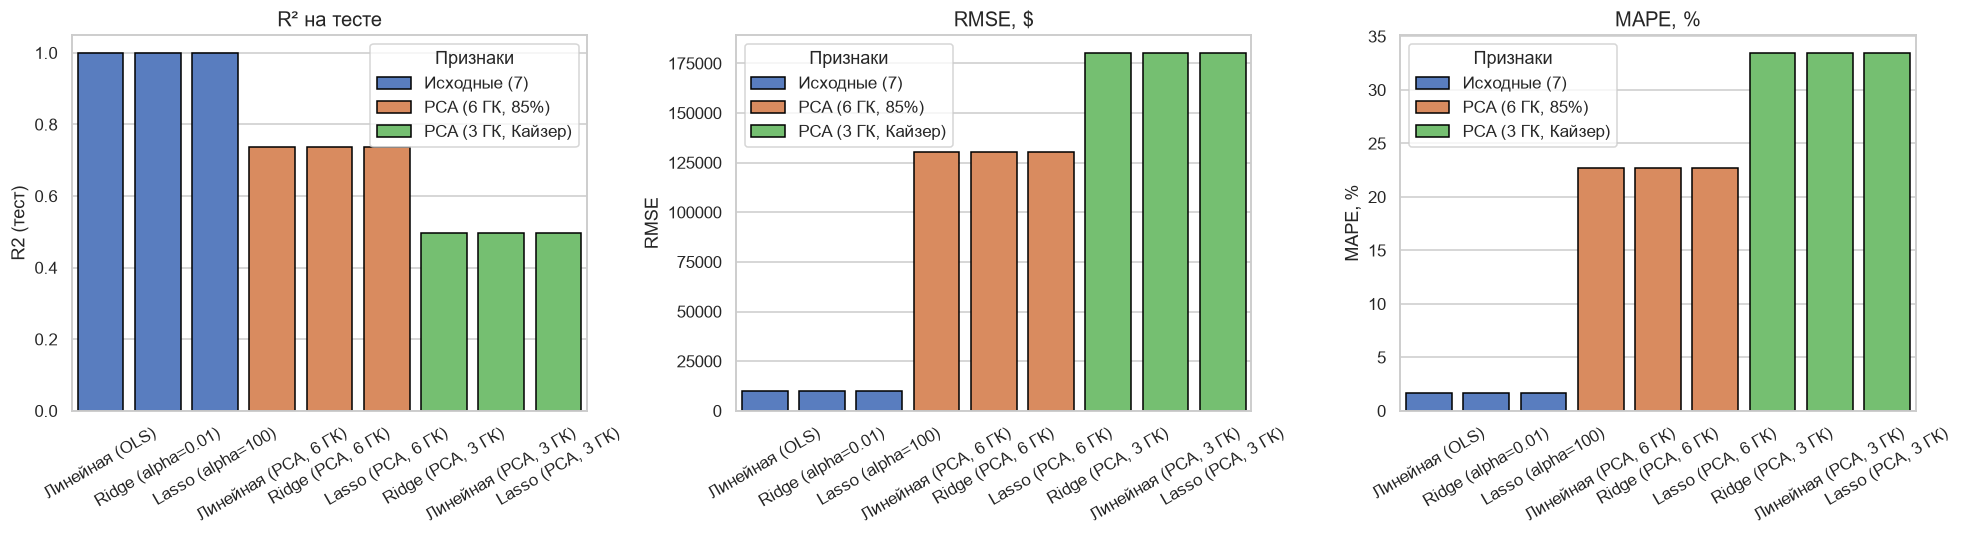

In [15]:
summary_rows = []
for name, res in results_orig.items():
    summary_rows.append({
        "Модель": name,
        "Признаки": f"Исходные ({len(feature_names)})",
        "R2 (CV)": res["R2_CV_mean"],
        "R2 (тест)": res["R2_Test"],
        "RMSE": res["RMSE_Test"],
        "MAPE, %": res["MAPE_Test"] * 100,
    })
for k, res_dict in results_pca_all.items():
    space = f"PCA ({k} ГК, {'Кайзер' if k == k_kaiser else '85%'})"
    for name, res in res_dict.items():
        summary_rows.append({
            "Модель": name,
            "Признаки": space,
            "R2 (CV)": res["R2_CV_mean"],
            "R2 (тест)": res["R2_Test"],
            "RMSE": res["RMSE_Test"],
            "MAPE, %": res["MAPE_Test"] * 100,
        })

summary = pd.DataFrame(summary_rows).sort_values("R2 (тест)", ascending=False).reset_index(drop=True)
print("Сводная таблица:")
display(summary.round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=summary, x="Модель", y="R2 (тест)", hue="Признаки", ax=axes[0], edgecolor="black")
axes[0].set_title("R² на тесте")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary, x="Модель", y="RMSE", hue="Признаки", ax=axes[1], edgecolor="black")
axes[1].set_title("RMSE, $")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary, x="Модель", y="MAPE, %", hue="Признаки", ax=axes[2], edgecolor="black")
axes[2].set_title("MAPE, %")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

### Пояснение к итоговому сравнению

1. **Лучший блок** — исходные признаки: $R^2 \approx 0.998$, RMSE ≈ $10$ тыс., MAPE ≈ $1.7\%$. После GridSearch Ridge/Lasso не обыгрывают OLS.
2. **6 ГК** заметно хуже; **3 ГК по Кайзеру** ещё хуже. PCA здесь не повышает точность.

In [16]:
weights_payload = {
    "датасет": "house_price_regression_dataset.csv",
    "обучающая_выборка": int(X_train.shape[0]),
    "тестовая_выборка": int(X_test.shape[0]),
    "подбор_гиперпараметров": {
        "сетка_alpha": alpha_grid["alpha"],
        "лучший_alpha_Ridge": best_ridge_alpha,
        "лучший_alpha_Lasso": best_lasso_alpha,
        "CV_R2_Ridge": float(ridge_search.best_score_),
        "CV_R2_Lasso": float(lasso_search.best_score_),
    },
    "модели_на_исходных_признаках": {
        name: {
            **res,
            "intercept": float(models_orig[name].intercept_),
            "coefficients": {
                col: float(coef) for col, coef in zip(feature_names, models_orig[name].coef_)
            },
        }
        for name, res in results_orig.items()
    },
    "факторный_анализ_pca": {
        "компонент_по_Кайзеру": int(k_kaiser),
        "компонент_по_порогу_85": int(k_var85),
        "подписи_компонент_из_нагрузок": {f"ГК_{i}": pc_labels[i] for i in pc_labels},
        "собственные_значения": [float(e) for e in eigenvalues],
        "факторные_нагрузки": {
            col: {f"ГК_{i}": float(loadings.loc[col, f"ГК {i}"]) for i in range(1, k_var85 + 1)}
            for col in feature_names
        },
    },
    "модели_на_главных_компонентах": {
        f"{k}_ГК": results_pca_all[k] for k in results_pca_all
    },
}

with open("laba1_model_weights.json", "w", encoding="utf-8") as f:
    json.dump(weights_payload, f, ensure_ascii=False, indent=2)

weights_csv_df = pd.DataFrame({
    "Признак": feature_names,
    "Линейная_регрессия_OLS": model_lin.coef_,
    "Гребневая_регрессия_Ridge": model_ridge.coef_,
    "Лассо_регрессия_Lasso": model_lasso.coef_,
})
weights_csv_df.to_csv("laba1_weights.csv", index=False)

print("Веса моделей:")
display(weights_csv_df.round(3))
print(f"Intercept линейной регрессии: {model_lin.intercept_:.2f} $")
print("Сохранены: laba1_model_weights.json, laba1_weights.csv")

Веса моделей:


,Признак,Линейная_регрессия_OLS,Гребневая_регрессия_Ridge,Лассо_регрессия_Lasso
0,Площадь,249787.915,249784.742,249692.530
1,Спальни,14524.734,14524.440,14430.132
2,Ванные,6695.907,6695.700,6606.058
3,Год постройки,20662.122,20661.789,20548.687
4,Участок,19088.111,19088.255,18999.974
5,Гараж,4219.449,4219.578,4132.738
6,Качество района,335.247,335.204,238.806


Intercept линейной регрессии: 618576.05 $
Сохранены: laba1_model_weights.json, laba1_weights.csv


### Пояснение к коэффициентам и файлам весов

Признаки стандартизованы, поэтому коэффициент показывает, на сколько долларов меняется прогноз цены при росте признака на одно стандартное отклонение.
Ранжирование влияния (по модулю коэффициента OLS):
- Площадь ≈ +249 788 — доминирующий предиктор. В исходных единицах это около $200 за 1 кв. фут. Согласуется с корреляцией 𝑟≈0.99.
- Год постройки ≈ +20 662 — более новые дома в среднем дороже.
- Участок ≈ +19 088 — крупный участок добавляет к цене, но слабее площади.
- Спальни ≈ +14 525 — умеренный положительный вклад.
- Ванные ≈ +6 696 — ещё слабее.
- Гараж ≈ +4 219 — небольшой плюс за дополнительное машино-место.
- Качество района ≈ +335 — практически нулевой вклад на фоне остальных.

Сравнение OLS / Ridge / Lasso. После подбора alpha (Ridge: 0.01, Lasso: 100) коэффициенты почти совпадают с OLS. Lasso сильнее всех сжимает слабые веса (особенно Качество района: 335 → ≈ 239), но порядок признаков и вывод не меняются: цена в основном определяется площадью.

Сохранённые файлы:
- laba1_weights.csv — таблица коэффициентов трёх моделей по каждому исходному признаку.
- laba1_model_weights.json — полный снимок эксперимента: размеры train/test, выбранные alpha, метрики RMSE/R²/MAPE, факторные нагрузки и результаты моделей на 3 и 6 главных компонентах.

## 5. Заключение

1. На датасете Home Value Insights построены OLS, Ridge и Lasso с метриками RMSE, R², MAPE.
2. В разделе **«Описание датасета»** — распределения, корреляции и VIF (все ≈ 1). Мультиколлинеарности нет.
3. Подготовка: train/test 80/20, `StandardScaler` только на train. Для Ridge/Lasso выполнен **GridSearchCV по `alpha`**: лучший штраф мал, сильная регуляризация CV-$R^2$ ухудшает — вывод «регуляризация не нужна» доказан перебором.
4. Лучшая модель — `model_lin` на исходных признаках: $R^2 \approx 0.998$, RMSE ≈ $10$ тыс., MAPE ≈ $1.7\%$. 
5. PCA: подписи ГК получены из нагрузок после расчёта. Сравнение **3 ГК (правило Кайзера)** и **6 ГК (85%)** показывает падение качества в обоих случаях; у 3 ГК просадка сильнее.
6. **Итог:** рабочая модель — линейная регрессия на стандартизованных исходных признаках; PCA и сильная регуляризация на этом наборе избыточны.

## 6. Список источников

1. Prokshitha P. Home Value Insights. — Kaggle, 2024. — https://www.kaggle.com/datasets/prokshitha/home-value-insights
2. Pedregosa F. et al. Scikit-learn: Machine Learning in Python // JMLR. — 2011. — Vol. 12. — P. 2825–2830.
3. James G. et al. An Introduction to Statistical Learning with Applications in Python. — Springer, 2023.
4. Флах П. Машинное обучение. — М.: ДМК Пресс, 2015.
5. Scikit-learn: Linear Models, PCA, GridSearchCV. — https://scikit-learn.org/stable/
6. Statsmodels: variance_inflation_factor. — https://www.statsmodels.org/

## 7. Приложение

- `laba1_analysis.py` — описание датасета, распределения, корреляции, VIF;
- `laba1_models.py` — train/test, GridSearchCV, `model_lin.fit`, PCA (3 и 6 ГК), сохранение весов.
